# Individual Project - Mia Di Marco 

## Table of Contents

1. Introduction
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Train/Validation Strategy
5. Model 1: Linear Support Vector Machine
6. Model 2: Random Forest
7. Model Comparison
8. Final Model Selection
9. Test Set Predictions
10. Conclusions
11. LLM Audit Section


## 1. Introduction

In this project, we address a binary classification problem using a tabular dataset composed of numerical and categorical features, with the presence of missing values and class imbalance. The goal is to build and compare two models, a linear Support Vector Machine and a Random Forest, within a well-defined preprocessing and validation framework, in order to identify the most suitable approach for this dataset.


## 2. Exploratory Data Analysis (EDA)

In [1]:
 #import
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import LinearSVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from scipy.stats import loguniform

palette = ["#f8bbd0", "#d81b60"]
sns.set_palette(palette)


### 2.1 Dataset Overview

In [2]:
#load data
data = pd.read_csv('mldata_0003284656.csv')
data.head()

,id,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,categorical_feature_1,categorical_feature_2,categorical_feature_3
0,0,0,-0.277072,-0.332123,0.660633,0.464365,-2.536543,0.694236,0.131588,-0.420923,...,2.133353,-0.071101,2.826191,1.120787,1.993556,0.203292,0.909538,G,A,C
1,1,0,0.116052,0.523027,-1.148715,0.261820,-0.926012,0.152244,-0.402813,-0.592152,...,-2.056545,-0.133211,-3.885620,0.144179,-2.848342,0.147874,-2.008657,A,B,A
2,2,1,-0.875515,-0.022954,-1.634422,0.011425,-0.069479,0.455602,1.181170,0.247362,...,1.473961,0.079346,-0.307548,0.368741,-7.760611,-0.657694,2.296470,C,A,G
3,3,1,0.320716,0.465791,0.186298,0.018090,-0.151497,-0.848996,0.620204,-0.163637,...,1.238548,0.176631,-1.151407,0.390734,8.729224,0.588551,0.868411,F,E,B
4,4,0,NaN,-0.077754,2.282048,-0.413434,-2.473213,0.714478,-0.438669,-0.270983,...,0.485613,-0.004489,-2.385509,-1.057122,-5.608677,-0.513613,NaN,D,NaN,C


In [3]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1300 non-null   int64  
 1   label                  1300 non-null   int64  
 2   feature_1              1217 non-null   float64
 3   feature_2              1214 non-null   float64
 4   feature_3              1300 non-null   float64
 5   feature_4              1300 non-null   float64
 6   feature_5              1218 non-null   float64
 7   feature_6              1300 non-null   float64
 8   feature_7              1300 non-null   float64
 9   feature_8              1300 non-null   float64
 10  feature_9              1194 non-null   float64
 11  feature_10             1204 non-null   float64
 12  feature_11             1300 non-null   float64
 13  feature_12             1300 non-null   float64
 14  feature_13             1208 non-null   float64
 15  feat

,id,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35
count,1300.000000,1300.000000,1217.000000,1214.000000,1300.000000,1300.000000,1218.000000,1300.000000,1300.000000,1300.000000,...,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1225.000000,1193.000000,1211.000000
mean,649.500000,0.408462,-0.115288,0.028919,0.165773,0.015334,0.181142,-0.459836,0.071899,-0.138815,...,-0.480149,0.100389,0.007696,0.254327,0.014625,-1.293288,0.103598,0.346367,-0.130209,0.186672
std,375.421985,0.491738,0.280081,0.236291,1.629263,0.286973,1.853095,1.213125,0.709272,0.400911,...,1.321347,0.205546,0.110015,3.373374,0.113793,4.176241,0.941148,4.384776,0.344062,1.746900
min,0.000000,0.000000,-1.059863,-0.723402,-5.702000,-0.814052,-6.021710,-4.233279,-2.213954,-1.846664,...,-5.053573,-0.555295,-0.391327,-10.735221,-0.407486,-14.606543,-3.224120,-14.178731,-1.232255,-5.252510
25%,324.750000,0.000000,-0.296739,-0.126912,-0.946812,-0.182311,-1.017729,-1.272025,-0.416069,-0.397182,...,-1.322539,-0.037318,-0.068650,-2.042400,-0.066360,-4.057946,-0.491921,-2.552100,-0.363961,-0.963708
50%,649.500000,0.000000,-0.118281,0.026261,0.208884,0.017166,0.175757,-0.474771,0.070209,-0.143583,...,-0.523322,0.098625,0.017139,0.313974,0.015192,-1.353094,0.108434,0.478617,-0.125612,0.170623
75%,974.250000,1.000000,0.056805,0.186116,1.269238,0.214573,1.364142,0.339899,0.566845,0.127964,...,0.425019,0.239922,0.081404,2.403428,0.092319,1.466886,0.765982,3.323469,0.100214,1.405013
max,1299.000000,1.000000,0.750004,0.705519,6.374258,0.926935,6.796696,3.892953,2.149835,1.201561,...,3.918858,0.828294,0.324127,12.069287,0.443873,12.158173,3.118453,12.625721,0.904072,5.694151


### 2.2 Target Variable Analysis

In [4]:
y = data["label"]

data = data.drop("label", axis=1)
data = data.drop("id", axis=1)

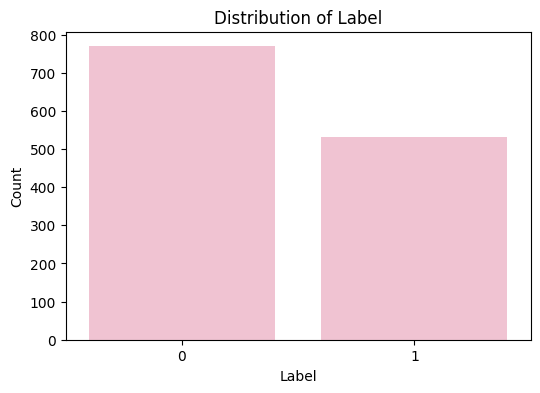

Ratio of classes:
label
0    0.591538
1    0.408462
Name: proportion, dtype: float64


In [5]:
data_plot = data.copy()
y_plot = y 

#distribution of label
plt.figure(figsize=(6,4))
sns.countplot(x=y_plot, data=data_plot)
plt.title('Distribution of Label')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()
ratio = y_plot.value_counts(normalize=True)
print("Ratio of classes:")
print(ratio)

- The dataset exhibits a class imbalance, with a predominance of zeros over ones (approximately 60:40). 

### 2.3 Numerical Features Analysis

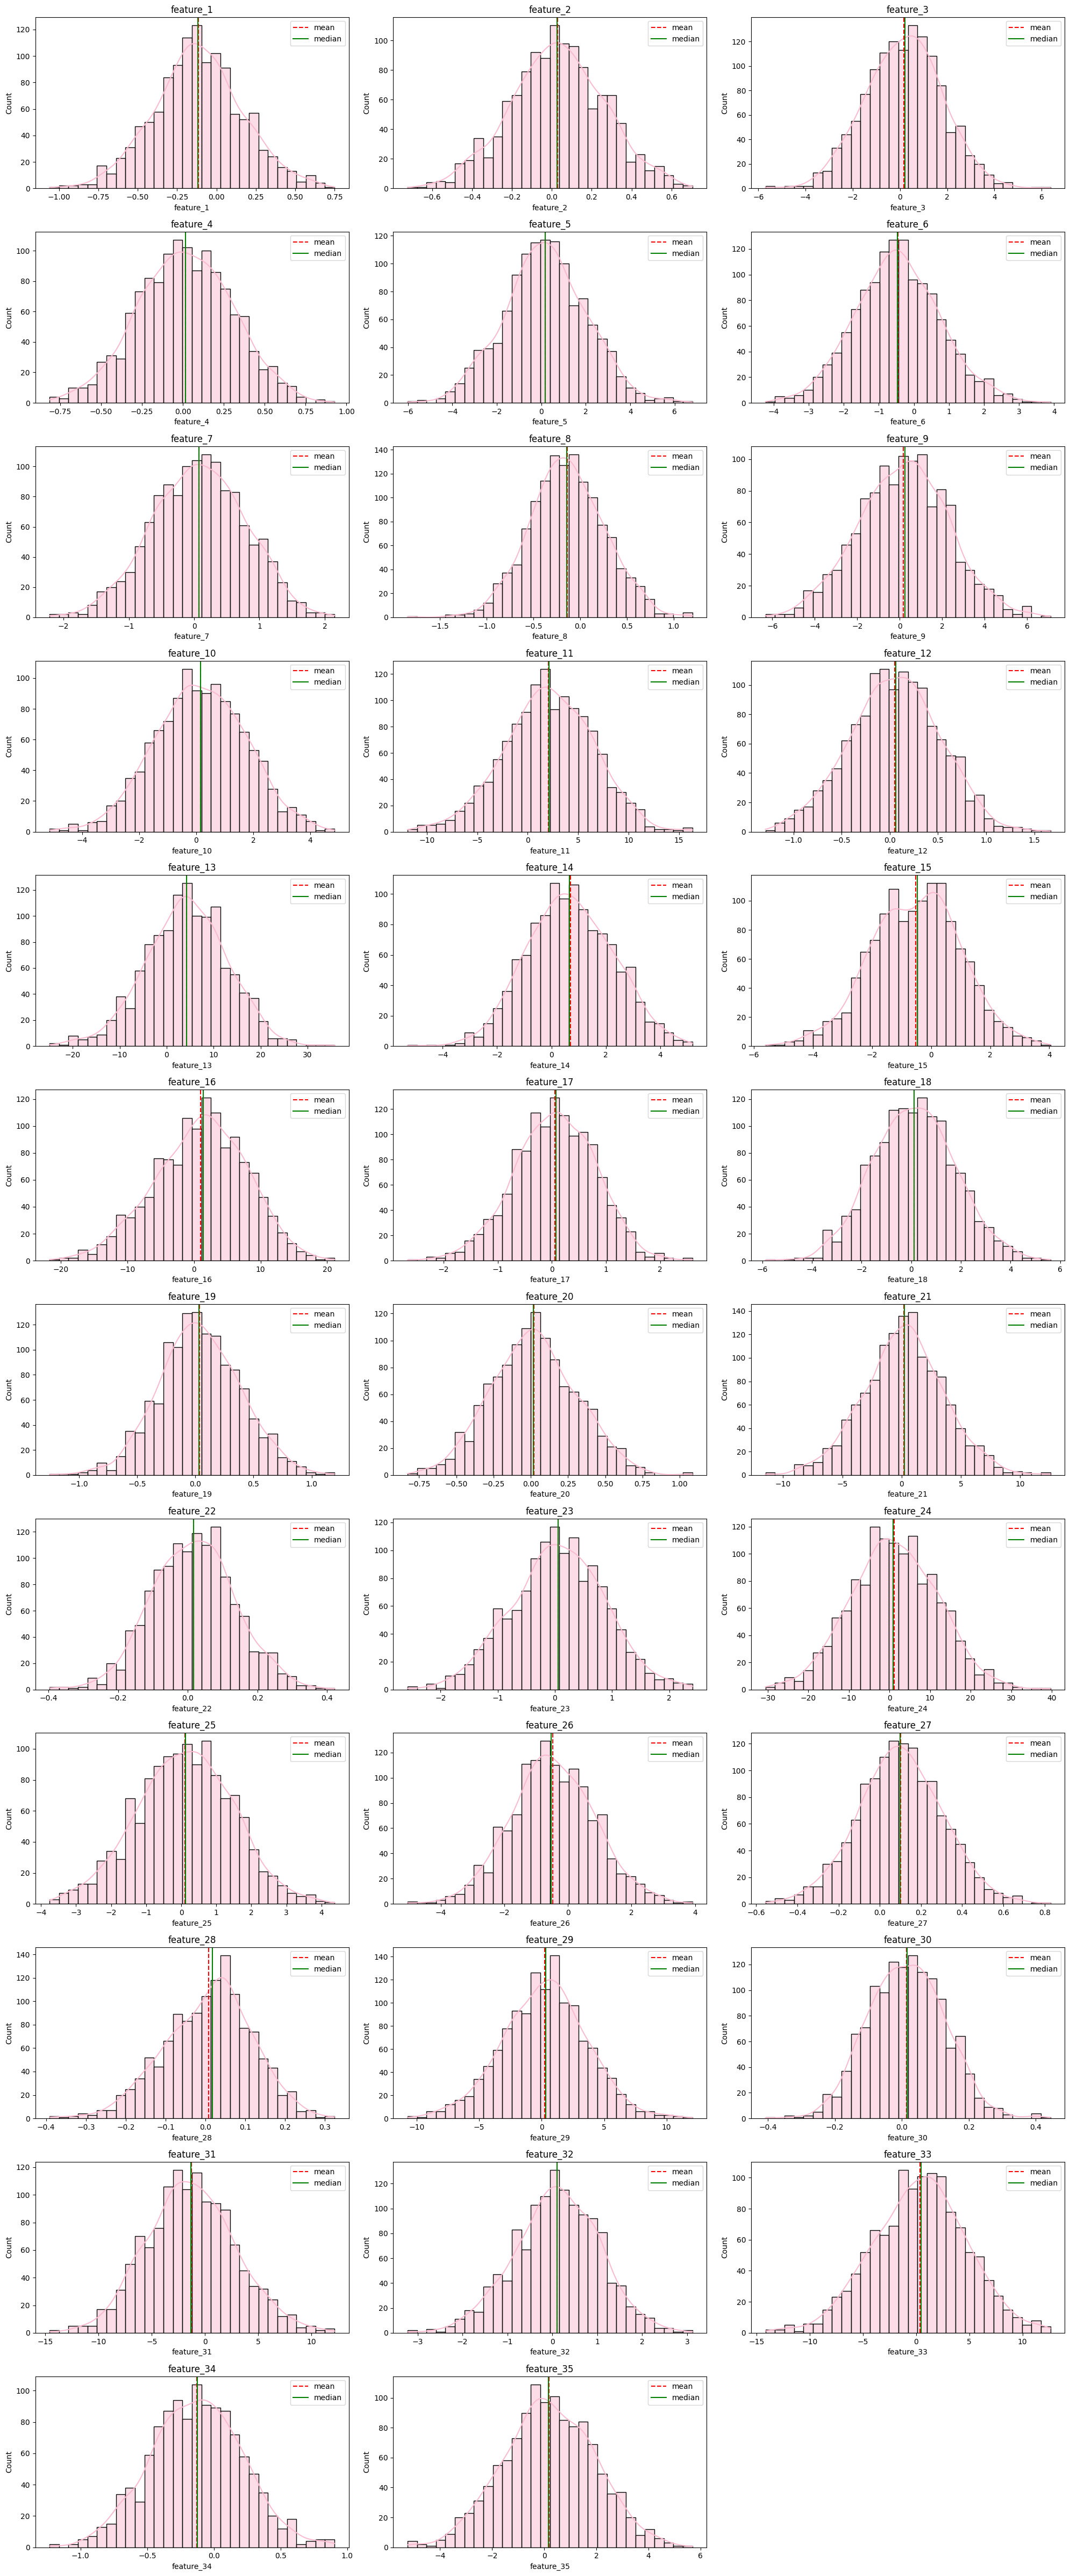

In [6]:
#distribution of numerical features
num_cols =  data_plot.drop(columns=['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3']).columns

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(data_plot[col], bins=30, kde=True, ax=ax)
    
    mean_val = data_plot[col].mean()
    median_val = data_plot[col].median()
    
    ax.axvline(mean_val, color='red', linestyle='--', label='mean')
    ax.axvline(median_val, color='green', linestyle='-', label='median')
    
    ax.set_title(col)
    ax.legend()


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Most numerical features exhibit approximately symmetric distributions. While some variables show mild skewness, no transformation was applied, as the deviations from normality are not substantial.

- Feature scaling (standardization) should be applied to ensure comparable ranges across variables, which is particularly important for models such as SVM that are sensitive to feature scale.

- No significant outliers were detected from the distribution analysis, suggesting that extreme values are not a major concern in this dataset.

- Overall, the distributions appear well-behaved and suitable for standard machine learning pipelines without requiring heavy preprocessing.

### 2.4 Categorical Features Analysis

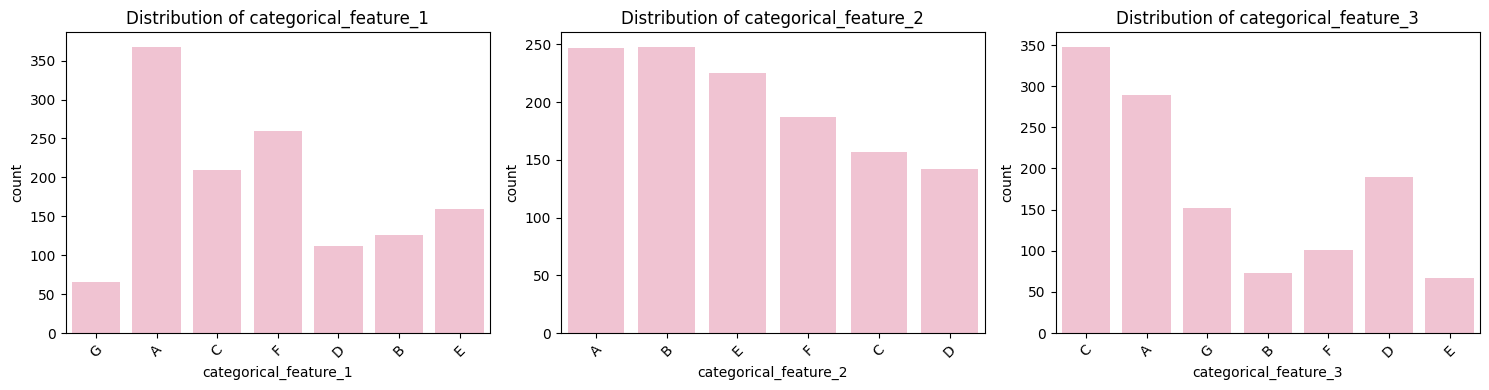

In [7]:
cat_cols = ['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3']

n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    sns.countplot(data=data_plot, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

- The overall distribution of categorical features appears relatively balanced across categories, without extreme dominance of specific values. This suggests that no category is overwhelmingly frequent, providing a good basis for modeling without strong imbalance issues

### 2.5 Missing Values Analysis

In [8]:
#check for missing values
data.isnull().mean().sort_values(ascending=False)

feature_14               0.096923
feature_34               0.082308
feature_9                0.081538
feature_20               0.079231
feature_10               0.073846
categorical_feature_2    0.072308
feature_13               0.070769
feature_35               0.068462
feature_2                0.066154
feature_1                0.063846
feature_5                0.063077
categorical_feature_3    0.061538
feature_33               0.057692
feature_12               0.000000
feature_3                0.000000
categorical_feature_1    0.000000
feature_4                0.000000
feature_32               0.000000
feature_31               0.000000
feature_30               0.000000
feature_29               0.000000
feature_28               0.000000
feature_27               0.000000
feature_26               0.000000
feature_11               0.000000
feature_24               0.000000
feature_23               0.000000
feature_22               0.000000
feature_21               0.000000
feature_6     

- Following the analysis of missing values, it emerges that both numerical and categorical features contain incomplete observations. In numerical variables, the presence of skewness and potential outliers suggests that robust summary statistics, such as the median, may be more appropriate than the mean for representing central tendency. For categorical variables, missing values are typically associated with the absence of a dominant category, indicating that imputation strategies based on the most frequent class may preserve the underlying distribution.

### 2.6 Feature–Target Relationship Analysis

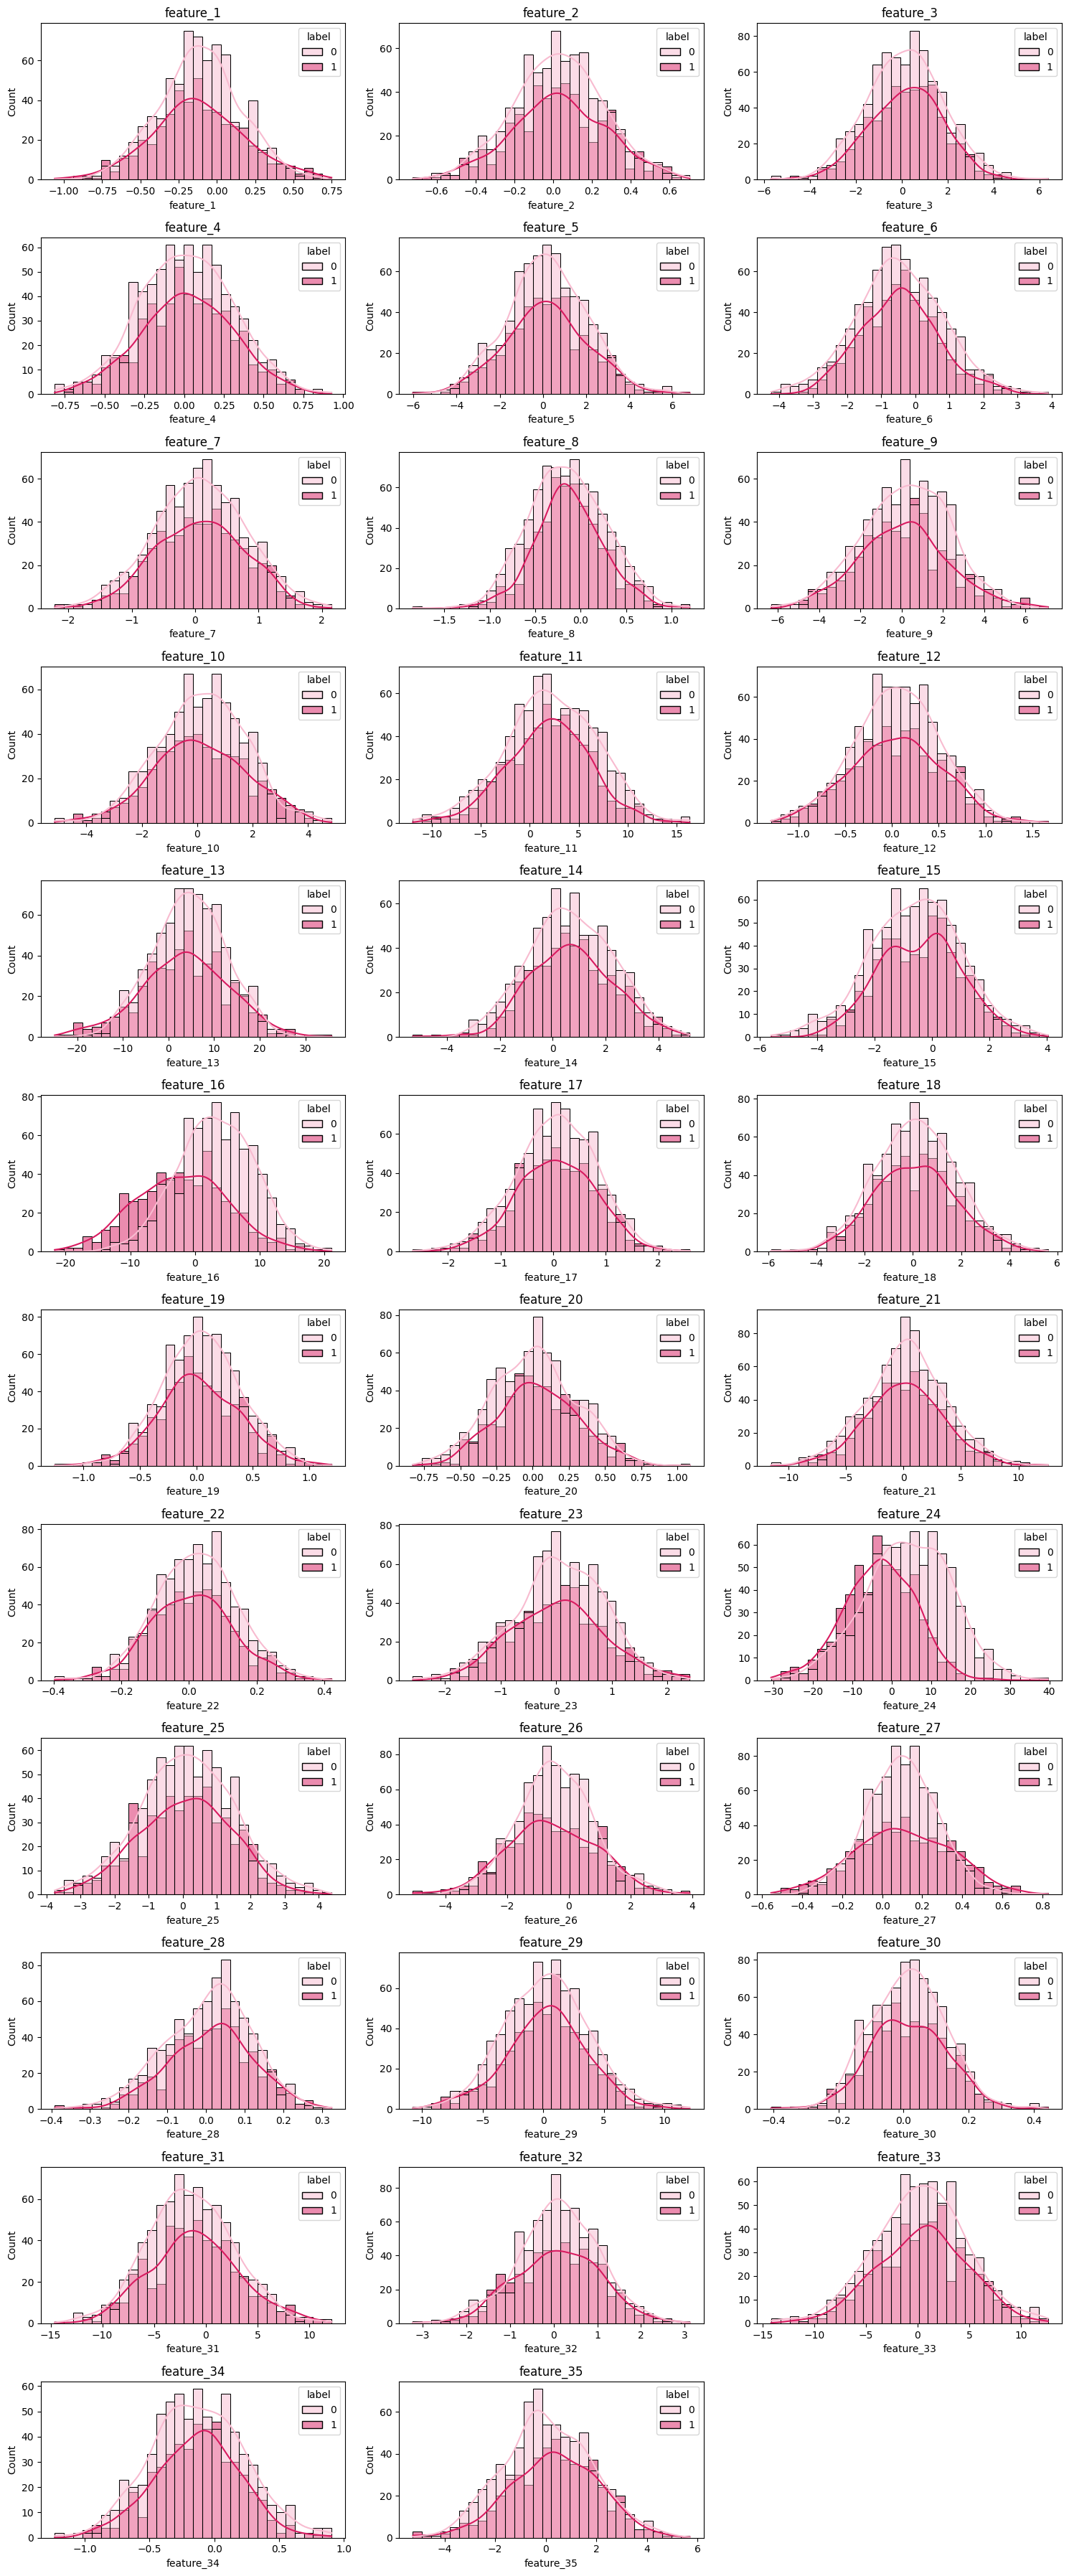

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    sns.histplot(
        data=data_plot,
        x=col,
        hue= y_plot,
        bins=30,
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
group_means = data_plot.groupby(y_plot)[num_cols].mean().T

diff = (group_means[1] - group_means[0]).abs()

diff.sort_values(ascending=False)

feature_24    7.197792
feature_16    5.294846
feature_13    0.814011
feature_31    0.455070
feature_11    0.277497
feature_35    0.273962
feature_15    0.166038
feature_33    0.164742
feature_9     0.110788
feature_26    0.106440
feature_10    0.060951
feature_14    0.052151
feature_29    0.048109
feature_3     0.044252
feature_18    0.043791
feature_25    0.041321
feature_21    0.037216
feature_23    0.028019
feature_20    0.024924
feature_5     0.022343
feature_32    0.021247
feature_19    0.021129
feature_8     0.021119
feature_6     0.016715
feature_17    0.014652
feature_12    0.012925
feature_22    0.012052
feature_27    0.009206
feature_28    0.008252
feature_2     0.006562
feature_1     0.006248
feature_7     0.005139
feature_34    0.003106
feature_4     0.002437
feature_30    0.000380
dtype: float64

- A visual inspection of the class-wise distributions suggests that most features exhibit a high degree of overlap between classes, limiting their individual discriminative ability.

- However, **features 16 and 24 stand out**, as they show comparatively lower overlap between the two classes. This indicates a stronger potential to distinguish between labels and suggests that these variables may play a more significant role in the classification task.

- This suggests that a subset of features may carry most of the predictive signal, which could be effectively captured by models capable of handling feature importance and non-linear interactions, such as Random Forests.

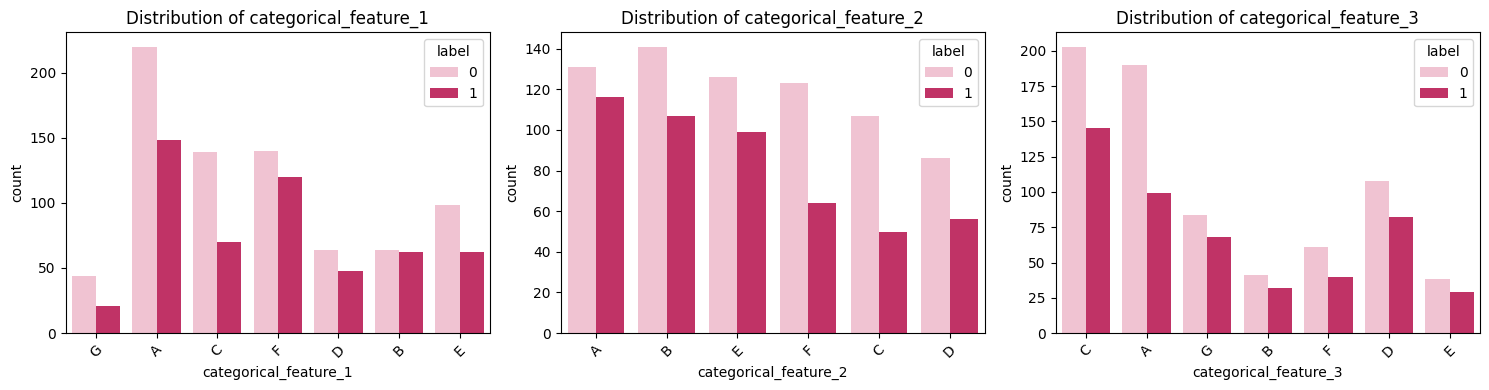

In [11]:
n_cols = 3
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    
    sns.countplot(data=data_plot, x=col, hue=y_plot, ax=ax, palette=palette)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

- When conditioned on the target, some categories show different frequencies across classes, indicating potential predictive power. However, the separation is not sharp, suggesting that individual categorical features alone are insufficient and need to be combined for effective classification.

### 2.7 Feature Relationships

<Axes: xlabel='feature_1', ylabel='feature_4'>

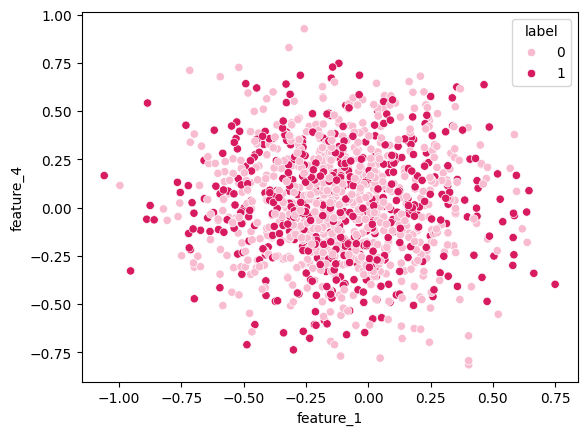

In [12]:
sns.scatterplot(x="feature_1", y="feature_4", hue= y_plot, data=data_plot)

- The scatter plot of **feature_1** versus **feature_4**, colored by class label, shows a strong overlap between the two classes. No clear separation or clustering structure is visible, indicating that the joint distribution of these two features does not provide significant discriminative power.

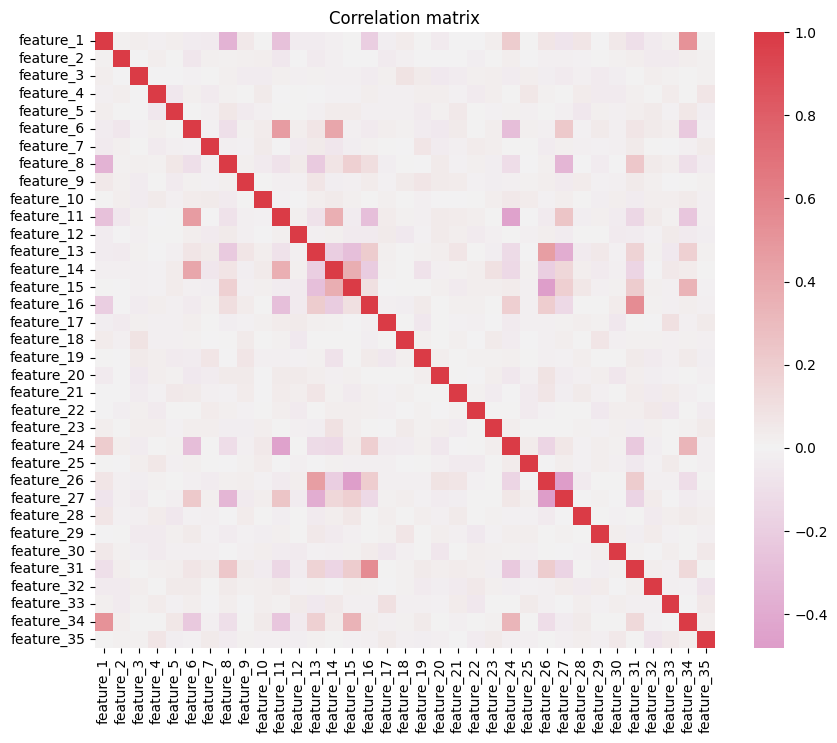

In [13]:
corr = data_plot[num_cols].corr()
plt.figure(figsize=(10,8))
cmap = sns.diverging_palette(330, 10, as_cmap=True) 
sns.heatmap(corr, cmap=cmap, center=0)
plt.title("Correlation matrix")
plt.show()

- The correlation matrix does not reveal strong linear relationships between the numerical features, as most pairwise correlations appear relatively low. 

- However, this does not necessarily imply independence, as potential **non-linear relationships** may still be present and are not captured by linear correlation measures. 

- Overall, no clear multicollinearity issues emerge, and feature selection does not appear strictly necessary at this stage based on linear dependencies alone.

### 2.8 Key Insights from EDA

The exploratory analysis reveals several important characteristics of the dataset. 
- First, most numerical features exhibit approximately symmetric distributions, suggesting that standard preprocessing techniques are likely to be sufficient. However, feature scaling will be important, particularly for models such as Support Vector Machines, which are sensitive to feature magnitude.
- Second, the analysis of feature–target relationships highlights a substantial overlap between classes across most variables, indicating limited linear separability. This suggests that more flexible models, such as Random Forests, may be better suited to capture complex patterns in the data.
- Additionally, a subset of features (notably feature_16 and feature_24) shows stronger class-wise differences, indicating potential predictive relevance and a higher contribution to the classification task.
- The presence of missing values across both numerical and categorical features requires appropriate handling during the preprocessing phase to ensure model robustness and consistency.
- At the same time, the overall structure of the data suggests that relationships between variables may not be fully captured by simple linear patterns, pointing to the potential presence of higher-order interactions that should be explored in the modeling phase.
- Finally, no strong multicollinearity issues are detected, and categorical features appear to provide moderate but not dominant predictive power. 
- Overall, the dataset appears suitable for standard machine learning approaches, with potential benefits from models capable of capturing non-linear relationships.

## 3. Data Preprocessing

In [14]:
cat_cols = ['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3']
num_cols =  data.drop(columns=['categorical_feature_1', 'categorical_feature_2', 'categorical_feature_3']).columns

# pipeline num
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# pipeline cat
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

The preprocessing pipeline is designed based on the insights from the exploratory analysis. 
- Missing values in numerical features are handled through median imputation, as this approach is robust to potential skewness and outliers. 
- Categorical variables are imputed using the most frequent category and encoded via one-hot encoding.
- Feature scaling is applied to numerical variables to ensure compatibility with models such as Support Vector Machines, which are sensitive to feature magnitude.

## 4. Train/Validation Strategy

### 4.1 Train/Test Split

In [15]:
X = data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

- A stratified train/test split is used to obtain an independent hold-out set for final model evaluation.

### 4.2 K_fold Cross Validation

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

- Stratified k-fold cross-validation is used during hyperparameter tuning to obtain a robust estimate of model performance while preserving class proportions across folds.

Cross-validation is used for model selection and hyperparameter tuning, as it allows for a more reliable performance estimate by averaging results across multiple folds. A separate hold-out test set is maintained for evaluation, ensuring that model performance is assessed on unseen data and preventing optimistic bias.

### 4.3 Evaluation Metrics

Given the presence of mild class imbalance in the target variable, model performance is evaluated using both accuracy and F1-score. While accuracy provides an overall measure of correctness, it may be misleading when class distributions are not perfectly balanced.
Therefore, the F1-score is also considered, as it balances precision and recall and provides a more informative assessment of model performance across both classes.

## 5. Model 1: Linear Support Vector Machine

### 5.1 Baseline Linear SVM

In [17]:
svm_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearSVC(class_weight="balanced", max_iter=10000, random_state=42))
])

cv_scores = cross_val_score(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

svm_pipeline.fit(X_train, y_train)

print("CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


CV F1 scores: [0.66666667 0.73015873 0.76666667 0.65116279 0.73033708]
Mean CV F1: 0.7089983865682846


### 2. Feature Expansion (Polynomial Features)

In [18]:
num_pipeline_poly = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False))
])

preprocessor_poly = ColumnTransformer([
    ("num", num_pipeline_poly, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

svm_poly_pipeline = Pipeline([
    ("preprocessing", preprocessor_poly),
    ("model", LinearSVC(class_weight="balanced", max_iter=10000))
])

In [19]:
param_dist_poly = {
    "preprocessing__num__poly__degree": [1, 2, 3],
    "model__C": loguniform(0.01, 10)
}

random_svm_poly = RandomizedSearchCV(
    estimator=svm_poly_pipeline,
    param_distributions=param_dist_poly,
    n_iter=10,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

random_svm_poly.fit(X_train, y_train)

print("Best params:", random_svm_poly.best_params_)
print("Best CV F1:", random_svm_poly.best_score_)

Best params: {'model__C': np.float64(0.011527987128232402), 'preprocessing__num__poly__degree': 2}
Best CV F1: 0.8216061693258336


The introduction of polynomial features leads to a significant improvement in model performance, with the cross-validated F1-score increasing from approximately 0.71 to 0.82. This suggests that non-linear interactions between features play an important role in the classification task.

The optimal model selects a polynomial degree of 2 and a relatively low regularization parameter, indicating that increased feature complexity requires stronger regularization to prevent overfitting.

While the model achieves perfect performance on the training set, suggesting a high degree of overfitting, the test performance remains strong (F1 ≈ 0.80), indicating that the model is still able to generalize reasonably well.

Overall, these results highlight the importance of non-linear feature interactions, while also emphasizing the trade-off between model flexibility and overfitting.

### 5.3 Regularization Comparison

In [20]:
svm_pipeline_l1 = Pipeline([
    ("preprocessing", preprocessor_poly),
    ("model", LinearSVC(
        penalty="l1",
        dual=False,
        class_weight="balanced",
        max_iter=10000
    ))
])



In [21]:
param_dist_l1 = {
    "preprocessing__num__poly__degree": [2],  # fissato dopo analisi precedente
    "model__C": loguniform(0.005, 1)
}

random_svm_l1 = RandomizedSearchCV(
    estimator=svm_pipeline_l1,
    param_distributions=param_dist_l1,
    n_iter=10,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)
random_svm_l1.fit(X_train, y_train)

print("Best params:", random_svm_l1.best_params_)
print("Best CV F1:", random_svm_l1.best_score_)



Best params: {'model__C': np.float64(0.011428087998532377), 'preprocessing__num__poly__degree': 2}
Best CV F1: 0.9093876464387103


- The introduction of L1 regularization in combination with polynomial feature expansion leads to a substantial improvement in model performance, with the cross-validated F1-score reaching approximately 0.90.

- By reducing the impact of less relevant polynomial features, the model is able to retain only the most informative interactions, resulting in a more robust and efficient representation of the data.

- Overall, these results highlight the importance of combining non-linear feature expansion with appropriate regularization to balance model flexibility and generalization.

### 5.4 Results

In [22]:
y_pred = svm_pipeline.predict(X_test)
y_pred_poly = random_svm_poly.predict(X_test)
y_pred_l1 = random_svm_l1.predict(X_test)

In [23]:
from sklearn.metrics import f1_score
results_summary = pd.DataFrame({
    "Model": [
        "SVM Baseline",
        "SVM Polynomial (L2)",
        "SVM Polynomial + L1"
    ],
    "Train F1": [
        f1_score(y_train, svm_pipeline.predict(X_train)),
        f1_score(y_train, random_svm_poly.predict(X_train)),
        f1_score(y_train, random_svm_l1.predict(X_train))
    ],
    "Test F1": [
        f1_score(y_test, svm_pipeline.predict(X_test)),
        f1_score(y_test, random_svm_poly.predict(X_test)),
        f1_score(y_test, random_svm_l1.predict(X_test))
    ]
})

results_summary

,Model,Train F1,Test F1
0,SVM Baseline,0.762542,0.734513
1,SVM Polynomial (L2),1.000000,0.801843
2,SVM Polynomial + L1,0.929845,0.909953


- The baseline SVM model achieves the weakest performance among the considered configurations. This result is consistent with the findings from the exploratory data analysis, which suggested that the relationship between the features and the target variable is not purely linear. Consequently, a linear decision boundary is unable to fully capture the underlying structure of the data and the potential non-linear interactions between variables.

- Introducing polynomial feature expansion substantially improves predictive performance, confirming the presence of non-linear patterns in the dataset. However, the SVM model with polynomial features and only L2 regularization exhibits clear signs of overfitting, as highlighted by the perfect training F1-score and the noticeable gap between training and test performance. This indicates that the model becomes excessively complex and adapts too closely to the training data.

- The best-performing configuration is obtained by combining polynomial feature expansion with L1 regularization. In this case, the regularization term acts as a complexity control mechanism by promoting sparsity and reducing the influence of less informative features. As a result, the model achieves a better balance between flexibility and generalization, leading to stronger and more stable performance on unseen data.

### 5.5 Feature Importance

In [24]:
best_model = random_svm_l1.best_estimator_

feature_names = best_model.named_steps["preprocessing"].get_feature_names_out()
coefficients = best_model.named_steps["model"].coef_[0]

print(len(feature_names), len(coefficients))

685 685


In [25]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})


display(
    coef_df.sort_values(by="coefficient", key=abs, ascending=False).head(10).style.format({"coefficient": "{:.3f}"})
)

,feature,coefficient
15,num__feature_16,-0.254
58,num__feature_1 feature_24,-0.199
267,num__feature_8 feature_16,-0.188
202,num__feature_6 feature_8,0.149
23,num__feature_24,-0.148
653,num__feature_31 feature_34,-0.124
611,num__feature_26 feature_27,0.121
450,num__feature_15 feature_31,0.117
10,num__feature_11,-0.101
282,num__feature_8 feature_31,-0.094


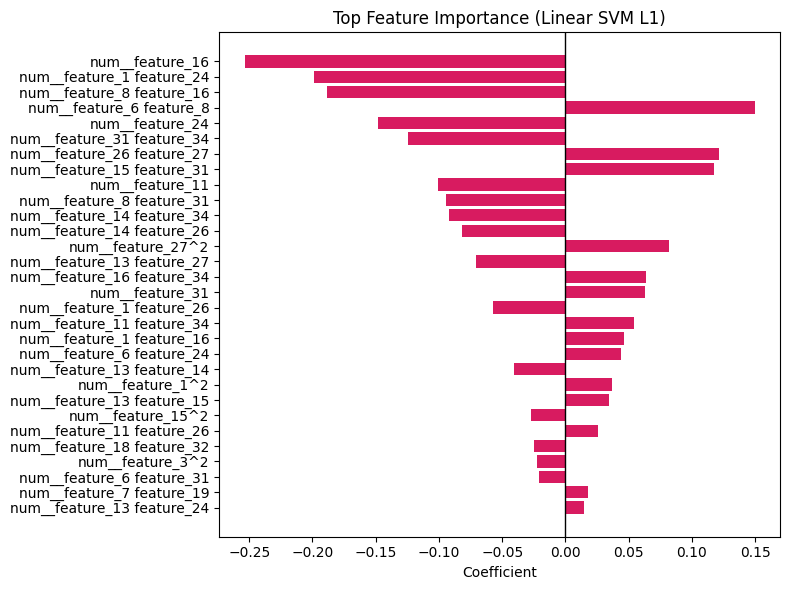

In [26]:
top_n = 30

top = coef_df.loc[
    coef_df["coefficient"].abs().sort_values(ascending=False).index
].head(top_n)

plt.figure(figsize=(8,6))

plt.barh(
    top["feature"][::-1],
    top["coefficient"][::-1],
    color="#d81b60"
)

plt.xlabel("Coefficient")
plt.title("Top Feature Importance (Linear SVM L1)")
plt.axvline(0, color="black", linewidth=1)

plt.tight_layout()
plt.show()

- Consistent with previous observations, **feature 16 and feature 24 appear among the most relevant variables**, either individually or through interaction terms. This confirms their key role in the classification task, as already suggested by the exploratory analysis.

- Notably, many of the top features correspond to **interaction terms between numerical variables**, indicating that the predictive signal is not driven by single features alone, but rather by combinations of multiple variables.

- Overall, the model relies on a distributed set of weak signals, combining them to construct an effective decision boundary despite the strong overlap between classes.

## 6. Model 2: Random Forest

### 6.1 Single Decision Tree Analysis

In [27]:
from sklearn.metrics import f1_score
tree_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train) 

y_pred_tree = tree_pipeline.predict(X_test)

print("Train F1:", f1_score(y_train, tree_pipeline.predict(X_train)))
print("Test F1:", f1_score(y_test, y_pred_tree))

Train F1: 0.7272727272727273
Test F1: 0.7355371900826446


A shallow decision tree (max depth = 3) is trained to provide an interpretable representation of the decision process. The limited depth allows for a clear visualization of the most important splits, highlighting the key variables driving the classification.

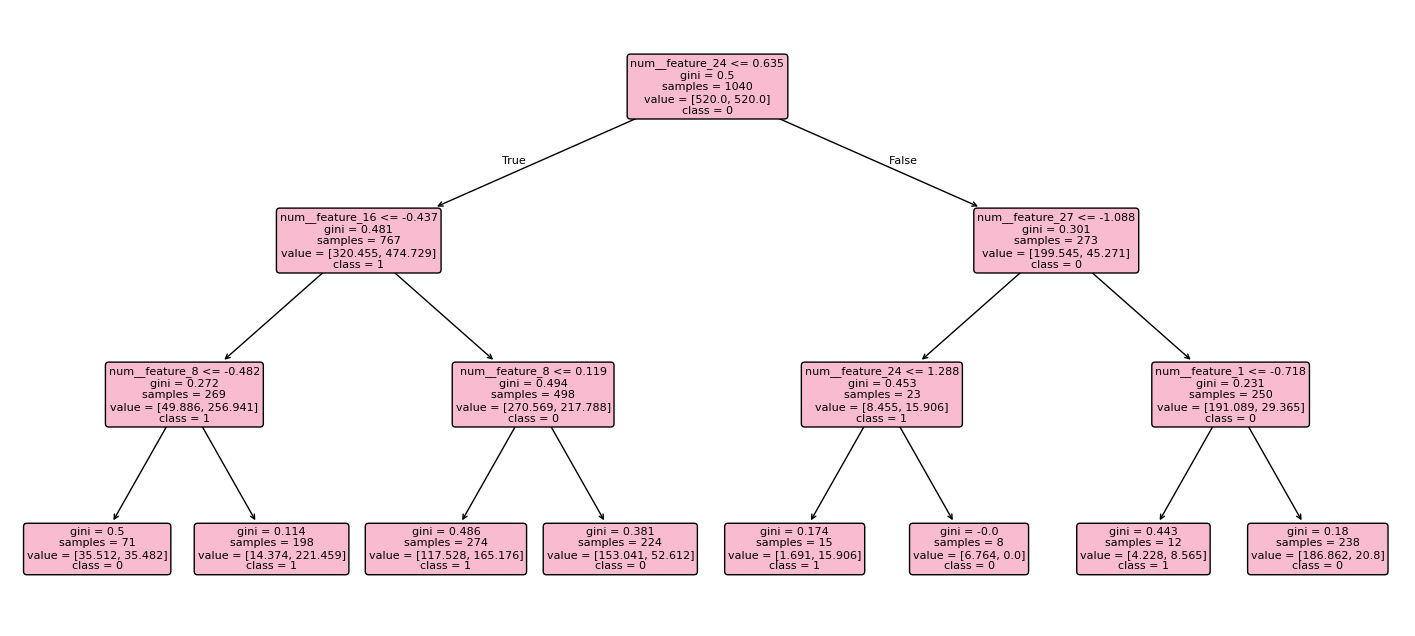

In [28]:
feature_names = tree_pipeline.named_steps["preprocessing"].get_feature_names_out()

plt.figure(figsize=(18, 8))

tree_plot = plot_tree(
    tree_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=8
)

for node in tree_plot:
    if node.get_bbox_patch() is not None:
        node.get_bbox_patch().set_facecolor("#f8bbd0")  # rosa chiaro

plt.show()

As previously observed in the exploratory analysis, **features 16 and 24 appear to play a key role in the classification task**. This is confirmed by the decision tree, where these variables are used in the top splits, indicating their strong discriminative power.


### 6.2 Random Forest Classifier

In [29]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

In [30]:
param_dist_rf_refined = {
    "model__n_estimators": [500, 750, 1000],
    "model__max_depth": [10, 15, 20, 25, 30, None],
    "model__min_samples_leaf": [3, 5, 7, 10],
    "model__min_samples_split": [10, 15, 20, 25],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True]
}

random_rf = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_rf_refined,
    n_iter=10,  # puoi aumentare se vuoi più esplorazione
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=2,
    refit=True
)

random_rf.fit(X_train, y_train)

print("Best params RF:", random_rf.best_params_)
print("Best CV f1 RF:", random_rf.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=500; total time=   2.9s
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=500; total time=   3.0s
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=500; total time=   3.1s
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=500; total time=   3.1s
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=500; total time=   3.1s
[CV] END model__bootstrap=True, model__

In [31]:
y_pred_rf = random_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       154
           1       0.88      0.77      0.82       106

    accuracy                           0.87       260
   macro avg       0.87      0.85      0.86       260
weighted avg       0.87      0.87      0.86       260



- The Random Forest model achieves strong performance, with an F1-score around 0.85–0.87 on the test set, indicating good generalization and the ability to capture non-linear relationships in the data.

### 6.3 Feature Importance

In [32]:
best_rf = random_rf.best_estimator_

rf_model = best_rf.named_steps["model"]
preprocessor = best_rf.named_steps["preprocessing"]

feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_k = 30
top_features = importance_df.head(top_k)

print(top_features)

            feature  importance
15  num__feature_16    0.167821
23  num__feature_24    0.136437
7    num__feature_8    0.070214
26  num__feature_27    0.053371
10  num__feature_11    0.039536
30  num__feature_31    0.038986
12  num__feature_13    0.034915
0    num__feature_1    0.034675
25  num__feature_26    0.030748
33  num__feature_34    0.028428
5    num__feature_6    0.027590
14  num__feature_15    0.026196
13  num__feature_14    0.018883
34  num__feature_35    0.015519
19  num__feature_20    0.014349
11  num__feature_12    0.014188
27  num__feature_28    0.014138
18  num__feature_19    0.014124
9   num__feature_10    0.013923
32  num__feature_33    0.013676
2    num__feature_3    0.013287
31  num__feature_32    0.012956
21  num__feature_22    0.012782
6    num__feature_7    0.012495
22  num__feature_23    0.012159
20  num__feature_21    0.012084
24  num__feature_25    0.011586
8    num__feature_9    0.011476
16  num__feature_17    0.011102
29  num__feature_30    0.011047


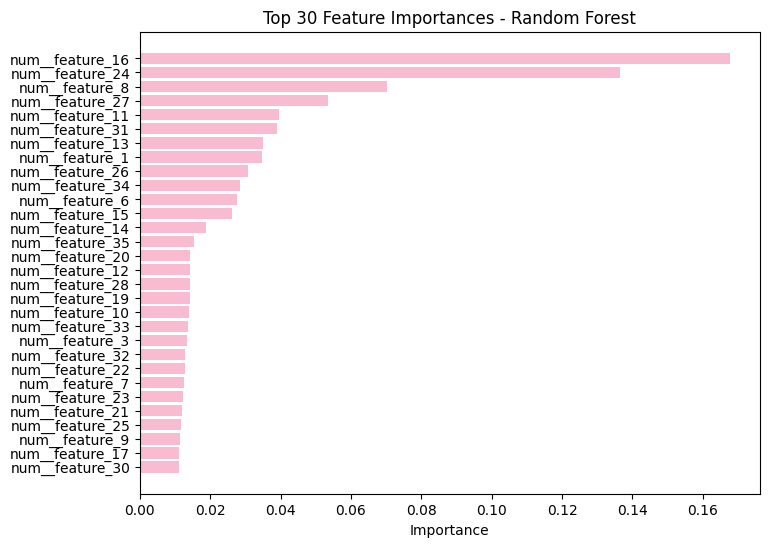

In [33]:
plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 30 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

- The feature importance analysis highlights a clear concentration of predictive power in a limited number of variables. In particular, feature_16 and feature_24 emerge as the most influential features, significantly outperforming all others.

- Additionally, while several other features contribute to the model, their importance is substantially lower, suggesting that the predictive signal is primarily driven by a small subset of variables.

## 7. Model Comparison

In [34]:
from sklearn.metrics import accuracy_score, f1_score
results = []
for name, model, cv_score in [
    ("Linear SVM (L1)", random_svm_l1, random_svm_l1.best_score_),
    ("Random Forest", random_rf, random_rf.best_score_)
]:
    results.append({
        "Model": name,
        "Best Params": model.best_params_,
        "CV F1 (mean)": cv_score,
    })

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,Best Params,CV F1 (mean)
0,Linear SVM (L1),"{'model__C': 0.011428087998532377, 'preprocess...",0.909
1,Random Forest,"{'model__n_estimators': 1000, 'model__min_samp...",0.786


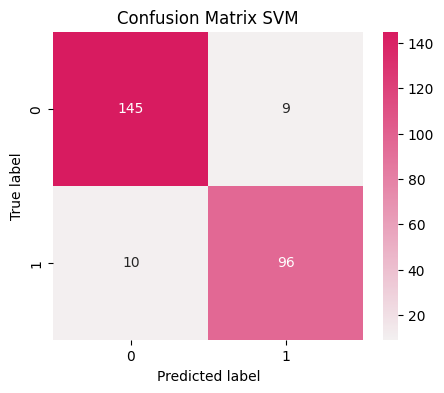

In [35]:
y_pred = random_svm_l1.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("#d81b60", as_cmap=True),  # rosa
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix SVM")
plt.show()

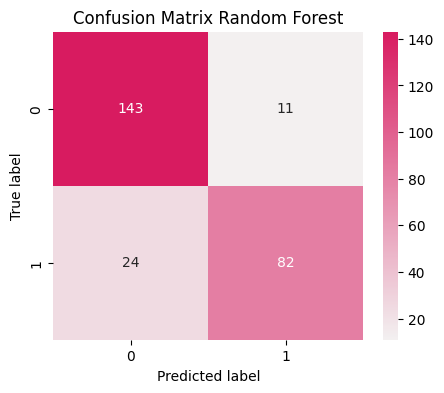

In [36]:
y_pred = random_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("#d81b60", as_cmap=True),  # rosa
    cbar=True
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Random Forest")
plt.show()

The comparison is based on the cross-validated F1-scores obtained during hyperparameter tuning. The test set is reserved for final evaluation only and is not used to drive model selection.
The Linear SVM achieves the highest cross-validated F1, confirming that combining polynomial feature expansion with L1 regularization effectively captures the most relevant feature interactions in the data.
The Random Forest also demonstrates solid cross-validated performance. While slightly lower, it offers advantages in terms of interpretability: it operates directly on the original feature space and provides intuitive feature importance measures without requiring explicit feature engineering.
Overall, the results suggest a trade-off between predictive performance and model interpretability, with the Linear SVM as the stronger choice on this dataset.


## 8. Final Model Selection

In [37]:
# Final evaluation on held-out test set
y_pred_final_eval = random_svm_l1.predict(X_test)
print("Test F1:", f1_score(y_test, y_pred_final_eval))
print("Test Accuracy:", accuracy_score(y_test, y_pred_final_eval))

Test F1: 0.909952606635071
Test Accuracy: 0.926923076923077


Based on the model comparison, the final model is a LinearSVC with L1 penalty, dual=False, class_weight="balanced", polynomial degree 2, and best selected C ≈ 0.0114 as it achieves the highest performance across all evaluation metrics.

## 9. Test Set Predictions

In [38]:
X_test_final = pd.read_csv("mldata_0003284656.TEST_FEATURES.csv")

y_pred_final = best_model.predict(X_test_final)

np.savetxt("submission.txt", y_pred_final, fmt="%d")

## 10. Conclusions

This project compared a Linear Support Vector Machine and a Random Forest for a binary classification task on a tabular dataset with numerical and categorical features, missing values, and mild class imbalance (approximately 60:40).

The exploratory analysis showed that most features exhibit substantial overlap between classes, with features 16 and 24 emerging consistently as the most discriminative — a finding confirmed across the class-wise distribution plots, the decision tree top splits, and the feature importance analyses of both models.

The best-performing model is a Linear SVM with polynomial features (degree=2) and L1 regularization, with a best C of approximately 0.011, achieving a test F1-score of approximately 0.91. The modeling progression — from a linear baseline, to polynomial expansion, to L1-regularized sparsity — demonstrates how explicitly encoding feature interactions, combined with appropriate regularization, allows a linear model to effectively capture non-linear structure in the data. 

The Random Forest, tuned via randomized search over depth, leaf size, and number of estimators, achieves a competitive test F1 of approximately 0.82–0.87 without requiring explicit feature engineering, and offers greater interpretability through its native feature importance scores.

**Limitations.**

The hyperparameter search was kept limited (n_iter=10) for computational reasons; a wider search could yield marginal improvements. Polynomial expansion substantially increases feature dimensionality, which may not scale well to larger datasets. Class imbalance was addressed via class_weight="balanced" but not explored further (e.g. SMOTE). Finally, no formal feature selection was performed, which could reduce model complexity without significant loss in performance.

## 11. LLM Audit Section

Since ChatGPT Edu was available, this project was developed with the support of this LLM. The purpose of this section is to critically assess the role that ChatGPT played in the analysis, highlighting both its strengths and its limitations.

On the positive side, ChatGPT was useful for quickly retrieving coding suggestions and supporting the implementation of Python code. It was also helpful in explaining syntax that I did not know or could not recall, allowing me to work more efficiently. Additionally, it assisted in rewriting draft paragraphs into clearer and more structured explanations. It also supported the organization of the notebook by suggesting section titles and helping structure the workflow in a more coherent way.

However, the use of ChatGPT also required careful supervision. Any code suggested by the model had to be double-checked, since the outputs were sometimes inconsistent or contained relatively simple mistakes. More importantly, the overall logic of the project had to remain under my control. Relying on ChatGPT for methodological decisions can be misleading, as its feedback may be unstable. For example, when I decided to explore polynomial features and L1 regularization, ChatGPT was initially skeptical and suggested not including them. However, after observing the results, it described the approach as highly effective. This shows that the model can be useful for discussion, but it should not be treated as a reliable source for deciding the analytical direction of the project.

Overall, ChatGPT was a valuable tool for speeding up coding, improving written explanations, and organizing the notebook. Nevertheless, its suggestions required continuous validation, and the main methodological choices had to be based on independent reasoning and critical judgment.

Prompt: **"I am working on a machine learning project for a course. I have a
tabular classification dataset with numerical features, categorical features, possible
missing values, and a hidden test set. Please propose a complete sklearn workflow
including EDA, preprocessing, train/validation strategy, model comparison,
hyperparameter tuning, evaluation metrics, and plots. Explain the reasoning behind each
step and provide Python code."**

ChatGPT EDU answer: *"I would approach this tabular classification problem using a structured and leakage-safe machine learning workflow.
First, I would perform exploratory data analysis (EDA) to understand the dataset. This includes checking the size of the dataset, inspecting feature types (numerical vs categorical), and analyzing the distribution of the target variable to detect class imbalance. I would also examine missing values across features, look at the distributions of numerical variables, and check the cardinality of categorical features. This step is important because it guides preprocessing choices and helps identify potential issues such as skewness, outliers, or data leakage.
Next, I would split the data into a training set and a validation set using a stratified split, so that the class proportions remain consistent across both sets. The validation set is kept completely separate and is only used at the end to evaluate the final model. This ensures that performance estimates are unbiased.
For preprocessing, I would treat numerical and categorical features differently. Numerical features would be imputed using the median to handle missing values and then scaled using standardization. Categorical features would be imputed using the most frequent value and then encoded using one-hot encoding. To ensure that preprocessing is applied consistently and without leakage, I would implement this using a Pipeline combined with a ColumnTransformer. This guarantees that transformations are learned only from the training data and correctly applied to validation and test data.
After preprocessing, I would perform model comparison using several baseline models such as logistic regression, random forest, gradient boosting, and support vector machines. I would evaluate these models using cross-validation on the training set, which provides a more robust estimate of performance than a single split. The choice of evaluation metrics depends on the dataset; for balanced datasets accuracy may be sufficient, but for imbalanced datasets I would prioritize metrics such as macro F1-score or balanced accuracy. ROC AUC can also be used if probability ranking is important.
Once a promising model is identified, I would perform hyperparameter tuning to improve its performance. Instead of grid search, I would use randomized search, which is more efficient and explores a wider range of parameter combinations. This tuning is still done using cross-validation to avoid overfitting.
After tuning, I would evaluate the best model on the validation set. At this stage, I would compute evaluation metrics such as accuracy, F1-score, and possibly ROC AUC, and also analyze a confusion matrix to understand where the model makes errors. For binary classification, I would also plot ROC and precision-recall curves to better understand performance, especially in the presence of class imbalance.
Finally, once the model and its hyperparameters are fully selected, I would retrain it on the entire training dataset (combining the original training and validation sets) to make full use of the available data. This final model is then used to generate predictions on the hidden test set. It is important that the hidden test set is never used during training or tuning, as it is meant to provide an unbiased estimate of generalization performance.
Overall, this workflow ensures a robust and reproducible approach, minimizes data leakage, and provides reliable performance evaluation."*



In this general setting, where no dataset or additional specific information was provided to ChatGPT, the proposed workflow is both useful and appropriate. The suggestions are correct precisely because they remain broad and rely on a standard, well-established approach to tabular machine learning problems. For this reason, there is little to criticize in the structure of the response.

One concrete omission worth noting is that ChatGPT suggests retraining the final model on the entire training dataset (combining training and validation sets) before generating test predictions, in order to make full use of the available data. This step was not performed in this project: the final model was trained only on the training split and applied directly to the hidden test set. While retraining on the full dataset is generally advisable in practice, it was omitted here for simplicity and to maintain a cleaner separation between the training and evaluation phases. This is a legitimate methodological choice, but it should be acknowledged as a difference from the LLM-suggested workflow.


However, it is also evident that the answer reflects a certain bias, as it mentions models such as logistic regression, Random Forest, and SVM, which I had already explored and developed with the support of ChatGPT in previous interactions. This suggests that the response is influenced by prior context rather than being entirely independent.

Overall, this response reinforces my previous conclusion: ChatGPT is a valuable tool for standard tasks such as writing code, structuring text, and outlining a general workflow, as demonstrated in this example. However, it lacks strong critical judgment and should not be relied upon for making key methodological decisions without independent reasoning and validation.